In [1]:
import os
import json
import glob
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALSModel
from pyspark.sql.functions import col, explode, desc

os.makedirs("/workspace/outputs/recommendations", exist_ok=True)

try:
    spark.stop()
except Exception:
    pass

spark = (
    SparkSession.builder
    .appName("9_Final_Recommendation_Demo")
    .master("spark://spark-master:7077")
    .config("spark.hadoop.fs.defaultFS", "hdfs://namenode:8020")
    .config("spark.driver.host", "notebook")
    .config("spark.driver.bindAddress", "0.0.0.0")
    .config("spark.executor.memory", "1g")
    .config("spark.driver.memory", "1g")
    .config("spark.executor.cores", "1")
    .config("spark.cores.max", "1")
    .config("spark.executor.instances", "1")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.ui.port", "4040")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

HDFS_RAW = "hdfs://namenode:8020/netflix-recsys/raw/ml-25m"
HDFS_GOLD = "hdfs://namenode:8020/netflix-recsys/gold"
HDFS_MODELS = "hdfs://namenode:8020/netflix-recsys/models"
HDFS_OUTPUTS = "hdfs://namenode:8020/netflix-recsys/outputs"

movies = spark.read.parquet(f"{HDFS_RAW}/movies")
ratings = spark.read.parquet(f"{HDFS_RAW}/ratings")
long_term_ratings = spark.read.parquet(f"{HDFS_GOLD}/long_term_ratings")

als_model = ALSModel.load(f"{HDFS_MODELS}/als_model")

print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/06 07:55:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Spark version: 3.5.8
Spark master: spark://spark-master:7077


In [2]:
summary_rows = [
    {
        "name": "ratings_raw",
        "description": "Toàn bộ rating gốc từ MovieLens 25M",
        "rows": ratings.count()
    },
    {
        "name": "movies_raw",
        "description": "Danh sách phim gốc",
        "rows": movies.count()
    },
    {
        "name": "long_term_ratings",
        "description": "Rating của nhóm thành viên dài hạn sau tiền xử lý",
        "rows": long_term_ratings.count()
    },
    {
        "name": "als_user_factors",
        "description": "Số user có vector trong ALS model",
        "rows": als_model.userFactors.count()
    },
    {
        "name": "als_item_factors",
        "description": "Số phim có vector trong ALS model",
        "rows": als_model.itemFactors.count()
    }
]

dataset_summary = pd.DataFrame(summary_rows)
dataset_summary.to_csv("/workspace/outputs/recommendations/final_dataset_summary.csv", index=False)
dataset_summary

,name,description,rows
0,ratings_raw,Toàn bộ rating gốc từ MovieLens 25M,25000095
1,movies_raw,Danh sách phim gốc,62423
2,long_term_ratings,Rating của nhóm thành viên dài hạn sau tiền xử lý,10772371
3,als_user_factors,Số user có vector trong ALS model,25945
4,als_item_factors,Số phim có vector trong ALS model,53779


In [3]:
from IPython.display import display, HTML
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

def display_full_width_df(df):
    table_html = df.to_html(
        index=False,
        escape=False,
        classes="custom-full-width-table"
    )
    html = f"""
    <style>
        .custom-table-wrapper {{
            width: 100% !important;
            direction: ltr !important;
            text-align: left !important;
        }}

        .custom-table-title {{
            width: 100% !important;
            text-align: left !important;
            direction: ltr !important;
            margin-top: 16px !important;
            margin-bottom: 8px !important;
        }}

        table.custom-full-width-table {{
            width: 100% !important;
            table-layout: fixed !important;
            border-collapse: collapse !important;
            direction: ltr !important;
            text-align: left !important;
        }}

        table.custom-full-width-table thead tr th,
        table.custom-full-width-table tbody tr th,
        table.custom-full-width-table tbody tr td {{
            border: 1px solid #ddd !important;
            padding: 8px !important;
            text-align: left !important;
            vertical-align: top !important;
            white-space: normal !important;
            word-wrap: break-word !important;
            overflow-wrap: break-word !important;
            direction: ltr !important;
        }}

        table.custom-full-width-table thead tr th {{
            font-weight: bold !important;
            background-color: #f5f5f5 !important;
        }}
    </style>

    <div class="custom-table-wrapper">
        {table_html}
    </div>
    """

    display(HTML(html))

### 1. Vai trò và kiểu đánh giá của từng model

Model,Vai trò,Bài toán,Input,Output,Metric phù hợp
Spark ALS,Mô hình khuyến nghị nền tảng / baseline,Dự đoán rating người dùng dành cho phim,"userId, movieId, rating","predicted_rating, Top-N recommendation","RMSE, MAE"
TensorFlow NCF,Mô hình học sâu cho dự đoán sở thích,Dự đoán xác suất user thích một phim,"user_idx, movie_idx, label",probability user likes movie,"Loss, Accuracy, AUC"


### 2. Kết quả đánh giá Spark ALS

Metric,Giá trị,Ý nghĩa
RMSE,0.778017,"Sai số dự đoán rating, càng thấp càng tốt"
MAE,0.604163,"Sai số tuyệt đối trung bình, càng thấp càng tốt"


### 3. Kết quả đánh giá TensorFlow NCF

Metric,Giá trị,Ý nghĩa
Loss,0.209645,"Binary Cross-Entropy Loss, càng thấp càng tốt"
Accuracy,0.929365,"Tỷ lệ dự đoán đúng nhãn thích/không thích, càng cao càng tốt"
AUC,0.972555,"Khả năng phân biệt mẫu positive và negative, càng gần 1 càng tốt"


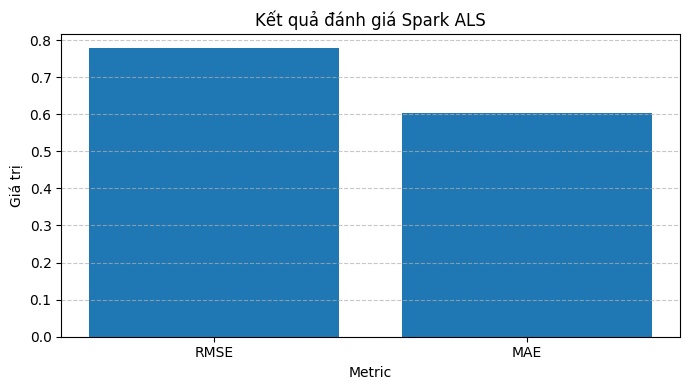

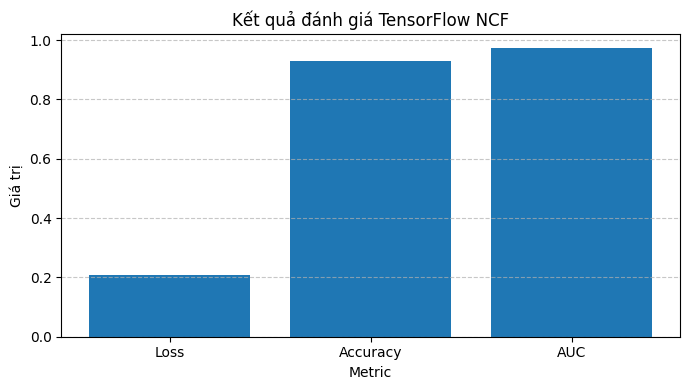

### 4. Nhận xét tổng hợp

Nội dung,Nhận xét
Spark ALS,Phù hợp để dự đoán rating và sinh Top-N recommendation trên dữ liệu lớn bằng Spark MLlib.
TensorFlow NCF,"Phù hợp để học quan hệ phi tuyến giữa user và movie, dự đoán xác suất user yêu thích phim."
Lưu ý so sánh,Không so sánh trực tiếp RMSE/MAE với Accuracy/AUC vì hai model giải quyết hai dạng bài toán đánh giá khác nhau.


In [4]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

os.makedirs("/workspace/outputs/recommendations", exist_ok=True)
os.makedirs("/workspace/outputs/figures", exist_ok=True)

def read_json_if_exists(path):
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None

def get_metric(data, *keys):
    if not data:
        return None
    for key in keys:
        if key in data:
            return data[key]
    return None

als_metrics = read_json_if_exists("/workspace/outputs/metrics/als_metrics.json")
ncf_metrics = read_json_if_exists("/workspace/outputs/metrics/ncf_metrics.json")

model_roles = pd.DataFrame([
    {
        "Model": "Spark ALS",
        "Vai trò": "Mô hình khuyến nghị nền tảng / baseline",
        "Bài toán": "Dự đoán rating người dùng dành cho phim",
        "Input": "userId, movieId, rating",
        "Output": "predicted_rating, Top-N recommendation",
        "Metric phù hợp": "RMSE, MAE"
    },
    {
        "Model": "TensorFlow NCF",
        "Vai trò": "Mô hình học sâu cho dự đoán sở thích",
        "Bài toán": "Dự đoán xác suất user thích một phim",
        "Input": "user_idx, movie_idx, label",
        "Output": "probability user likes movie",
        "Metric phù hợp": "Loss, Accuracy, AUC"
    }
])

display(Markdown("### 1. Vai trò và kiểu đánh giá của từng model"))
display_full_width_df(model_roles)

model_roles.to_csv(
    "/workspace/outputs/recommendations/final_model_roles.csv",
    index=False
)

# 2. Bảng metric riêng cho ALS
als_table = pd.DataFrame([
    {
        "Metric": "RMSE",
        "Giá trị": get_metric(als_metrics, "rmse"),
        "Ý nghĩa": "Sai số dự đoán rating, càng thấp càng tốt"
    },
    {
        "Metric": "MAE",
        "Giá trị": get_metric(als_metrics, "mae"),
        "Ý nghĩa": "Sai số tuyệt đối trung bình, càng thấp càng tốt"
    }
])

display(Markdown("### 2. Kết quả đánh giá Spark ALS"))
display_full_width_df(als_table)

als_table.to_csv(
    "/workspace/outputs/recommendations/final_als_metrics.csv",
    index=False
)

# 3. Bảng metric riêng cho NCF
ncf_table = pd.DataFrame([
    {
        "Metric": "Loss",
        "Giá trị": get_metric(ncf_metrics, "loss"),
        "Ý nghĩa": "Binary Cross-Entropy Loss, càng thấp càng tốt"
    },
    {
        "Metric": "Accuracy",
        "Giá trị": get_metric(ncf_metrics, "accuracy", "binary_accuracy"),
        "Ý nghĩa": "Tỷ lệ dự đoán đúng nhãn thích/không thích, càng cao càng tốt"
    },
    {
        "Metric": "AUC",
        "Giá trị": get_metric(ncf_metrics, "auc"),
        "Ý nghĩa": "Khả năng phân biệt mẫu positive và negative, càng gần 1 càng tốt"
    }
])

display(Markdown("### 3. Kết quả đánh giá TensorFlow NCF"))
display_full_width_df(ncf_table)

ncf_table.to_csv(
    "/workspace/outputs/recommendations/final_ncf_metrics.csv",
    index=False
)

als_plot = als_table.dropna(subset=["Giá trị"])

if not als_plot.empty:
    plt.figure(figsize=(7, 4))
    plt.bar(als_plot["Metric"], als_plot["Giá trị"])
    plt.title("Kết quả đánh giá Spark ALS")
    plt.xlabel("Metric")
    plt.ylabel("Giá trị")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("/workspace/outputs/figures/final_als_metrics.png", dpi=200, bbox_inches="tight")
    plt.show()

ncf_plot = ncf_table.dropna(subset=["Giá trị"])

if not ncf_plot.empty:
    plt.figure(figsize=(7, 4))
    plt.bar(ncf_plot["Metric"], ncf_plot["Giá trị"])
    plt.title("Kết quả đánh giá TensorFlow NCF")
    plt.xlabel("Metric")
    plt.ylabel("Giá trị")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.savefig("/workspace/outputs/figures/final_ncf_metrics.png", dpi=200, bbox_inches="tight")
    plt.show()

comparison_summary = pd.DataFrame([
    {
        "Nội dung": "Spark ALS",
        "Nhận xét": "Phù hợp để dự đoán rating và sinh Top-N recommendation trên dữ liệu lớn bằng Spark MLlib."
    },
    {
        "Nội dung": "TensorFlow NCF",
        "Nhận xét": "Phù hợp để học quan hệ phi tuyến giữa user và movie, dự đoán xác suất user yêu thích phim."
    },
    {
        "Nội dung": "Lưu ý so sánh",
        "Nhận xét": "Không so sánh trực tiếp RMSE/MAE với Accuracy/AUC vì hai model giải quyết hai dạng bài toán đánh giá khác nhau."
    }
])

display(Markdown("### 4. Nhận xét tổng hợp"))
display_full_width_df(comparison_summary)

comparison_summary.to_csv(
    "/workspace/outputs/recommendations/final_model_comparison_summary.csv",
    index=False
)

In [5]:
valid_users = als_model.userFactors.select(col("id").alias("userId"))

demo_user_id = int(valid_users.limit(1).toPandas()["userId"].iloc[0])

demo_user_id

3

In [6]:
def show_user_liked_movies(user_id: int, limit: int = 10):
    liked = (
        ratings
        .filter((col("userId") == user_id) & (col("rating") >= 4.0))
        .join(movies, "movieId", "left")
        .orderBy(col("rating").desc())
        .limit(limit)
    )

    pdf = liked.toPandas()
    out_path = f"/workspace/outputs/recommendations/user_{user_id}_liked_movies.csv"
    pdf.to_csv(out_path, index=False)
    return pdf

liked_movies = show_user_liked_movies(demo_user_id, 10)
liked_movies

,movieId,userId,rating,timestamp,title,genres
0,541,3,5.0,1439474625,Blade Runner (1982),Action|Sci-Fi|Thriller
1,1217,3,5.0,1439474455,Ran (1985),Drama|War
2,741,3,5.0,1484753808,Ghost in the Shell (Kôkaku kidôtai) (1995),Animation|Sci-Fi
3,778,3,5.0,1484753842,Trainspotting (1996),Comedy|Crime|Drama
4,1213,3,5.0,1484754156,Goodfellas (1990),Crime|Drama
5,858,3,5.0,1439474389,"Godfather, The (1972)",Crime|Drama
6,214,3,5.0,1484753888,Before the Rain (Pred dozhdot) (1994),Drama|War
7,924,3,5.0,1439474638,2001: A Space Odyssey (1968),Adventure|Drama|Sci-Fi
8,296,3,5.0,1439474476,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
9,1148,3,5.0,1439474452,Wallace & Gromit: The Wrong Trousers (1993),Animation|Children|Comedy|Crime


In [7]:
def recommend_for_user(user_id: int, top_n: int = 10):
    user_df = spark.createDataFrame([(int(user_id),)], ["userId"])

    recs = als_model.recommendForUserSubset(user_df, top_n)

    result = (
        recs
        .select("userId", explode("recommendations").alias("rec"))
        .select(
            "userId",
            col("rec.movieId").alias("movieId"),
            col("rec.rating").alias("predicted_rating")
        )
        .join(movies, "movieId", "left")
        .orderBy(col("predicted_rating").desc())
    )

    pdf = result.toPandas()
    out_path = f"/workspace/outputs/recommendations/user_{user_id}_als_top_{top_n}.csv"
    pdf.to_csv(out_path, index=False)
    return pdf

als_recommendations = recommend_for_user(demo_user_id, 10)
als_recommendations

,movieId,userId,predicted_rating,title,genres
0,203086,3,5.646881,Truth and Justice (2019),Drama
1,183947,3,5.445360,NOFX Backstage Passport 2,(no genres listed)
2,184299,3,5.379397,Freedom on My Mind (1994),Documentary
3,165559,3,5.353659,Ο Θανάσης στη χώρα της σφαλιάρας (1976),(no genres listed)
4,151615,3,5.260718,Hello Stranger (2010),Drama
5,196787,3,5.259805,The Law and the Fist (1964),Drama|War
6,166812,3,5.239198,Seeing Red: Stories of American Communists (1983),(no genres listed)
7,157791,3,5.237783,.hack Liminality In the Case of Kyoko Tohno,(no genres listed)
8,157787,3,5.237783,.hack Liminality: In the Case of Mai Minase,(no genres listed)
9,192089,3,5.213948,"National Theatre Live: One Man, Two Guvnors (2011)",Comedy


In [8]:
liked_movie_ids = set(liked_movies["movieId"].tolist())
recommended_movie_ids = set(als_recommendations["movieId"].tolist())

overlap = liked_movie_ids.intersection(recommended_movie_ids)

demo_summary = {
    "demo_user_id": demo_user_id,
    "num_liked_movies_displayed": len(liked_movies),
    "num_recommended_movies": len(als_recommendations),
    "overlap_between_liked_and_recommended": len(overlap),
    "recommendation_output_file": f"/workspace/outputs/recommendations/user_{demo_user_id}_als_top_10.csv"
}

with open("/workspace/outputs/recommendations/final_demo_summary.json", "w", encoding="utf-8") as f:
    json.dump(demo_summary, f, ensure_ascii=False, indent=2)

pd.DataFrame([demo_summary])

,demo_user_id,num_liked_movies_displayed,num_recommended_movies,overlap_between_liked_and_recommended,recommendation_output_file
0,3,10,10,0,/workspace/outputs/recommendations/user_3_als_top_10.csv


In [9]:
final_outputs = []

for pattern in [
    "/workspace/outputs/recommendations/*.csv",
    "/workspace/outputs/recommendations/*.json",
    "/workspace/outputs/metrics/*.json",
    "/workspace/outputs/figures/*.png",
]:
    for path in glob.glob(pattern):
        final_outputs.append({
            "file": path,
            "size_kb": round(os.path.getsize(path) / 1024, 2)
        })

final_outputs_df = pd.DataFrame(final_outputs).sort_values("file")
final_outputs_df.to_csv("/workspace/outputs/recommendations/final_output_files.csv", index=False)
final_outputs_df

,file,size_kb
20,/workspace/outputs/figures/avg_rating_by_genre.png,86.60
21,/workspace/outputs/figures/final_als_metrics.png,42.13
22,/workspace/outputs/figures/final_ncf_metrics.png,39.39
23,/workspace/outputs/figures/genre_distribution.png,85.69
24,/workspace/outputs/figures/long_term_user_distribution.png,68.93
25,/workspace/outputs/figures/model_comparison.png,37.51
26,/workspace/outputs/figures/ncf_training_loss.png,87.43
30,/workspace/outputs/figures/rating_distribution.png,61.23
27,/workspace/outputs/figures/ratings_by_year.png,120.54
28,/workspace/outputs/figures/ratings_per_movie_distribution.png,73.73
